In [ ]:
import torch
import sys
sys.path.append('../')
from utilities import load_embedding
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.optim import AdamW

In [ ]:
import torch.nn.functional as F
import os
from tqdm import tqdm

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)

    return pd.DataFrame(merged_rows)

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

NameError: name 'Dataset' is not defined

In [24]:
device = torch.device('cuda:0')
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
new_columns = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d',
                'seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat', 'label']
data_path = '/data/chenyihao/dataset'

Crick_all = pd.read_csv(data_path + '/all.csv')
dataframe = Crick_all.groupby(group_columns).agg({'seq_id_a': 'first', 'seq_id_b': 'first', 'seq_id_c': 'first', 'seq_id_d': 'first',
                                                    'seq_type_a': 'first', 'seq_type_b': 'first', 'seq_type_c': 'first', 'seq_type_d': 'first',
                                                    'label': 'mean'}).reset_index()
Crick_all_final = dataframe[new_columns]

CDC_all = pd.read_csv(data_path + '/CDC_all.csv')
dataframe = CDC_all.groupby(group_columns).agg({'seq_id_a': 'first', 'seq_id_b': 'first', 'seq_id_c': 'first', 'seq_id_d': 'first',
                                                    'seq_type_a': 'first', 'seq_type_b': 'first', 'seq_type_c': 'first', 'seq_type_d': 'first',
                                                    'serumType': 'first', 'serumName': 'first', 'virusName': 'first','label': 'mean'}).reset_index()
CDC_all_final = dataframe[new_columns + ['serumType', 'serumName', 'virusName']]

Artificial_all = pd.read_csv(data_path + '/Artificial_data.csv')
dataframe = Artificial_all.groupby(group_columns).agg({'seq_id_a': 'first', 'seq_id_b': 'first', 'seq_id_c': 'first', 'seq_id_d': 'first',
                                                       'label': 'mean'}).reset_index()
Artificial_all_final = dataframe[new_columns]

train_data, test_data = train_test_split(Crick_all_final, test_size=0.1, random_state=42)
train_data, valid_data = train_test_split(train_data, test_size=1/9, random_state=42)
train_data = pd.concat([train_data, Artificial_all_final])

In [25]:
train_dataset = LucaDataset(train_data)
valid_dataset = LucaDataset(valid_data)
test_dataset = LucaDataset(test_data)

batch_size = 8
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Compare the uncertainty of train, test and CDC dataset

In [33]:
model = torch.load('../../model/model_001.pth', weights_only=False)

In [ ]:
# load embedding
IDs, embeddings = load_embedding("/data/chenyihao/embedding")
embeddings = [emb.to(device) for emb in embeddings]
emb_dict = dict(zip(IDs, embeddings))

Loading tensor: 100%|██████████| 6419/6419 [18:01<00:00,  5.94file/s]


In [160]:
CDC_candidate, CDC_test = train_test_split(CDC_all_final, test_size=0.2, random_state=42)

CDC_candidate_dataset = LucaDataset(CDC_candidate)
CDC_test_dataset = LucaDataset(CDC_test)

CDC_candidate_dataloader = DataLoader(CDC_candidate_dataset, shuffle=False)
CDC_test_dataloader = DataLoader(CDC_test_dataset, shuffle=False)

In [8]:
len(CDC_test)

1973

In [38]:
def monte_carlo_preds(model, dataloader, T=20):
    all_preds = []
    all_labels = []
    seed_base = 42
    model.train()
    Total_iter = T*len(dataloader)
    progress_bar = tqdm(range(Total_iter), desc="Monte Carlo Predictions")
    for t in range(T):
        for batch in dataloader:
            with torch.no_grad():
                matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in batch[0]])
                matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in batch[1]])
                matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in batch[2]])
                matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in batch[3]])
                strainPassCats, labels = batch[4], batch[5]
                # matrixs_a, matrixs_b, matrixs_c, matrixs_d, \
                # masks_a, masks_b, masks_c, masks_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device), \
                # masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
                masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
                strainPassCats, labels = strainPassCats.to(device), labels.to(device)

                torch.manual_seed(seed_base + t)
                torch.cuda.manual_seed_all(seed_base + t)
                
                _, _, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
                all_preds.append([item[0].item() for item in output])
                all_labels.append(labels)
                progress_bar.update(1)
    
    progress_bar.close()
    return all_preds, all_labels

In [21]:
dropout_rate = 0.2
for module in model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.p = dropout_rate

In [22]:
train_sampled_dataloader = DataLoader(LucaDataset(train_data.sample(6000,random_state=42)), batch_size=80)
trainS_preds, trainS_labels = monte_carlo_preds(model, train_sampled_dataloader, T=20)

Monte Carlo Predictions:   0%|          | 0/1500 [00:00<?, ?it/s]

Monte Carlo Predictions: 100%|██████████| 1500/1500 [09:26<00:00,  2.65it/s]


In [23]:
train_pred_df = list2df(trainS_preds,len(train_sampled_dataloader))
train_var = train_pred_df.var(axis=0)
print('The mean variance of train set is: ', train_var.mean())

The mean variance of train set is:  0.0858272359380096


In [24]:
test_sampled_dataloader = DataLoader(LucaDataset(test_data.sample(6000,random_state=42)), batch_size=80)
testS_preds, testS_labels = monte_carlo_preds(model, test_sampled_dataloader, T=20)

Monte Carlo Predictions:   0%|          | 0/1500 [00:00<?, ?it/s]

Monte Carlo Predictions: 100%|██████████| 1500/1500 [09:26<00:00,  2.65it/s]


In [25]:
test_pred_df = list2df(testS_preds,len(test_sampled_dataloader))
test_var = test_pred_df.var(axis=0)
print('The mean variance of test set is: ', test_var.mean())

The mean variance of test set is:  0.08526545938569167


In [26]:
CDC_sample_dataloader = DataLoader(LucaDataset(CDC_candidate.sample(6000,random_state=42)), batch_size=80)
CDCS_preds, CDCS_labels = monte_carlo_preds(model, CDC_sample_dataloader, T=20)

Monte Carlo Predictions:   0%|          | 0/1500 [00:00<?, ?it/s]

Monte Carlo Predictions: 100%|██████████| 1500/1500 [09:27<00:00,  2.64it/s]


In [28]:
CDC_pred_df = list2df(CDCS_preds,len(CDC_sample_dataloader))
CDC_var = CDC_pred_df.var(axis=0)
print('The mean variance of test set is: ', CDC_var.mean())

The mean variance of test set is:  0.10021928613584284


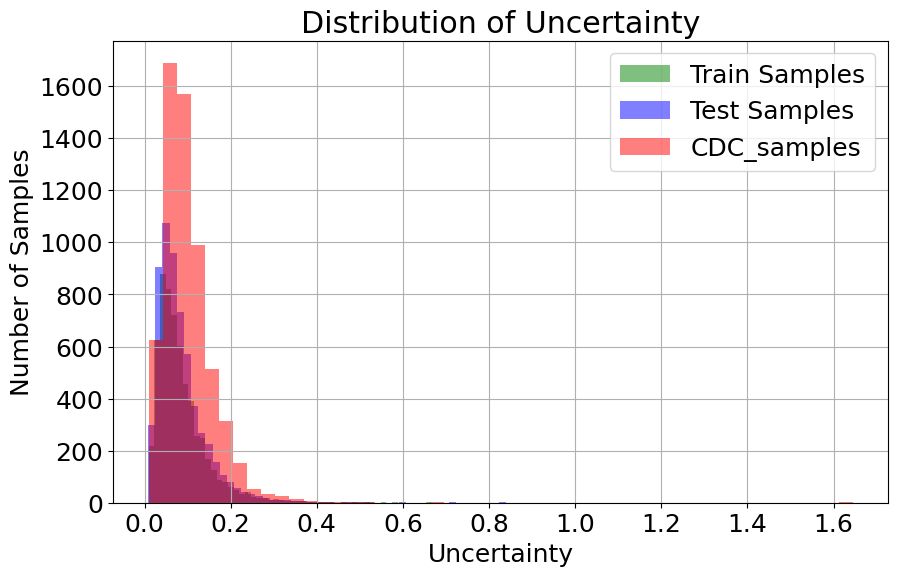

: 

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# 假设的数据
np.random.seed(0)
train_samples = train_var.values
test_samples = test_var.values
cdc_samples = CDC_var.values

# 创建直方图
plt.figure(figsize=(10, 6))
plt.hist(train_samples, bins=50, alpha=0.5, label='Train Samples', color='green')
plt.hist(test_samples, bins=50, alpha=0.5, label='Test Samples', color='blue')
plt.hist(cdc_samples, bins=50, alpha=0.5, label='CDC_samples', color='red')

# 添加标题和标签
plt.title('Distribution of Uncertainty')
plt.xlabel('Uncertainty')
plt.ylabel('Number of Samples')

# 添加图例
plt.legend()

# 显示网格
plt.grid(True)
# plt.xlim(0, 0.7)

# 显示图形
plt.show()

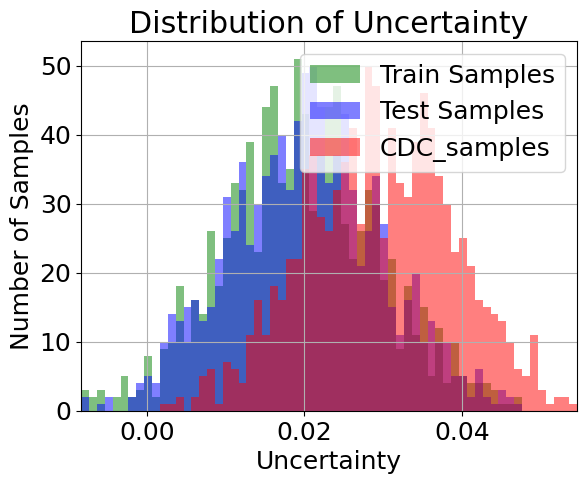

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# 假设的数据
np.random.seed(0)
train_samples = np.random.normal(0.02, 0.01, 1000)
test_samples = np.random.normal(0.02, 0.01, 1000)
cdc_samples = np.random.normal(0.03, 0.01, 1000)

# 定义函数来去除极端值
def remove_outliers(data, z_threshold=3):
    mean = np.mean(data)
    std = np.std(data)
    filtered_data = data[(np.abs(data - mean) < z_threshold * std)]
    return filtered_data

# 去除极端值
train_samples = remove_outliers(train_samples)
test_samples = remove_outliers(test_samples)
cdc_samples = remove_outliers(cdc_samples)

# 计算最小值和最大值
min_value = min(train_samples.min(), test_samples.min(), cdc_samples.min())
max_value = max(train_samples.max(), test_samples.max(), cdc_samples.max())

# 创建等间隔的分箱边界
bins = np.linspace(min_value, max_value, int((max_value - min_value) * 1000) + 2)

# 创建直方图
plt.hist(train_samples, bins=bins, alpha=0.5, label='Train Samples', color='green')
plt.hist(test_samples, bins=bins, alpha=0.5, label='Test Samples', color='blue')
plt.hist(cdc_samples, bins=bins, alpha=0.5, label='CDC_samples', color='red')

# 添加标题和标签
plt.title('Distribution of Uncertainty')
plt.xlabel('Uncertainty')
plt.ylabel('Number of Samples')

# 添加图例
plt.legend()

# 显示网格
plt.grid(True)

# 限制x轴范围
plt.xlim(min_value, max_value)

# 显示图形
plt.show()

## 比较使用特征向量聚类后，提取代表性序列

In [22]:
dropout_rate = 0.1
for module in model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.p = dropout_rate

In [23]:
test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in CDC_candidate_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])
    
    matrixs_a = matrixs_a.to(device)
    matrixs_b = matrixs_b.to(device)
    matrixs_c = matrixs_c.to(device)
    matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/mnt/chenyihao/workspace/001/CDC_train')
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())

test_mae = mean_absolute_error(test_reference_ls, test_prediction_ls)
test_mse = mean_squared_error(test_reference_ls, test_prediction_ls)
test_pearson = pearsonr(test_reference_ls, test_prediction_ls)
test_spearman = spearmanr(test_reference_ls, test_prediction_ls)

print(f"Test MAE: {test_mae}")
print(f"Test MSE: {test_mse}")
print(f"Test Pearson: {test_pearson}")
print(f"Test Spearman: {test_spearman}")

Test MAE: 1.2019301210310607
Test MSE: 2.4114243472910943
Test Pearson: PearsonRResult(statistic=0.7109599780224308, pvalue=0.0)
Test Spearman: SignificanceResult(statistic=0.7231209815080034, pvalue=0.0)


In [24]:
dict_path = '/mnt/chenyihao/workspace/001/CDC_train'
files = os.listdir(dict_path)
files = sorted(files, key=lambda x: int(x.replace('.pth', '')))
my_tensors = []
for file in files:
    my_tensors.append(torch.load(os.path.join(dict_path, file)))
CDC_candidate_tensor = torch.cat(my_tensors, dim=0).cpu().numpy()

In [25]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

kmeans = KMeans(n_clusters=500, random_state=42, n_init=10)
kmeans.fit(CDC_candidate_tensor)
centers = kmeans.cluster_centers_
distances = cdist(centers, CDC_candidate_tensor)
representative = distances.argmin(axis=1)

CDC_active_selected = CDC_candidate.iloc[representative]
CDC_random_selected = CDC_candidate.sample(500, random_state=42)

In [27]:
CDC_test_dataset = LucaDataset(CDC_test)
CDC_test_dataloader = DataLoader(CDC_test_dataset, batch_size=8, shuffle=False)

model_random = torch.load('/mnt/chenyihao/workspace/trained_models/001.pth')
model_random.to(device)

LucaQuadruple_final_dropout(
  (matrix_dropout): Dropout(p=0.1, inplace=False)
  (matrix_pooler): GlobalMaskValueAttentionPooling1D (2560 -> 2560)
  (linear): ModuleList(
    (0): ModuleList(
      (0): Linear(in_features=2560, out_features=256, bias=True)
      (1): GELU(approximate='none')
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (hidden_layer): Linear(in_features=1280, out_features=256, bias=True)
  (hidden_act): GELU(approximate='none')
  (classifier): Linear(in_features=256, out_features=1, bias=True)
  (loss_fct): MaskedMSELoss(
    (criterion): MSELoss()
  )
  (Passage_encoder): Sequential(
    (0): Embedding(5, 256)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
)

In [151]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def multidata_trainer(model, selected_data, epoch=20):
    model.to(device)
    no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
    weight_decay = 0.01
    beta1 = 0.9
    beta2 = 0.99
    adam_epsilon = 1e-08

    optimizer_grouped_parameters = [{
                "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
                "weight_decay": weight_decay
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
                "weight_decay": 0.0
            }
        ]
    optimizer = AdamW(optimizer_grouped_parameters,
                        lr=0.00005,
                        betas=[beta1 if beta1 > 0 else 0.9, beta2 if beta2 > 0 else 0.98],
                        eps=adam_epsilon)


    CDC_MAE_ls = []
    CDC_MSE_ls = []
    CDC_Pearson_ls = []
    CDC_Spearman_ls = []
    Crick_MAE_ls = []
    Crick_MSE_ls = []
    Crick_Pearson_ls = []
    Crick_Spearman_ls = []
    for epoch in range(epoch):
        old_data = train_data.sample(1000, random_state=epoch+1)
        new_dataset = LucaDataset(pd.concat([old_data, selected_data]))
        new_dataloader = DataLoader(new_dataset, batch_size=8, shuffle=True)
        model.train()
        loss_ls = []
        for batch in new_dataloader:
            matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in batch[0]])
            matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in batch[1]])
            matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in batch[2]])
            matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in batch[3]])
            strainPassCats, labels = batch[4], batch[5]

            matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
            masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
            strainPassCats, labels = strainPassCats.to(device), labels.to(device)
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                        matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                        matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_ls.append(loss.item())
        # print('The train loss: ',np.mean(loss_ls))

        CDC_test_prediction_ls = []
        CDC_test_reference_ls = []
        CDC_test_logits_ls = []
        model.eval()
        for batch in CDC_test_dataloader:
            with torch.no_grad():
                matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in batch[0]])
                matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in batch[1]])
                matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in batch[2]])
                matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in batch[3]])
                strainPassCats, labels = batch[4], batch[5]

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d, strainPassCats, labels = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device), strainPassCats.to(device), labels.to(device)
                loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                            matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                            matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
            CDC_test_prediction_ls = CDC_test_prediction_ls + output.view(-1).tolist()
            CDC_test_reference_ls = CDC_test_reference_ls + labels.tolist()
            CDC_test_logits_ls.append(logits.tolist())
        CDC_test_mae = mean_absolute_error(CDC_test_reference_ls, CDC_test_prediction_ls)
        CDC_test_mse = mean_squared_error(CDC_test_reference_ls, CDC_test_prediction_ls)
        CDC_test_pearson = pearsonr(CDC_test_reference_ls, CDC_test_prediction_ls)
        CDC_test_spearman = spearmanr(CDC_test_reference_ls, CDC_test_prediction_ls)
        CDC_MAE_ls.append(CDC_test_mae)
        CDC_MSE_ls.append(CDC_test_mse)
        CDC_Pearson_ls.append(CDC_test_pearson)
        CDC_Spearman_ls.append(CDC_test_spearman)

        # print(f"CDC Test MAE: {test_mae}")
        # print(f"CDC Test MSE: {test_mse}")
        # print(f"CDC Test Pearson: {test_pearson}")
        # print(f"CDC Test Spearman: {test_spearman}")

        ## 每5个epoch在Crick上测试一次

        if epoch % 5 == 0:
            Crick_test_prediction_ls = []
            Crick_test_reference_ls = []
            Crick_test_logits_ls = []
            model.eval()
            for batch in test_dataloader:
                matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in batch[0]])
                matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in batch[1]])
                matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in batch[2]])
                matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in batch[3]])
                strainPassCats, labels = batch[4], batch[5]

                matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
                masks_a, masks_b, masks_c, masks_d = masks_a.to(device), masks_b.to(device), masks_c.to(device), masks_d.to(device)
                strainPassCats, labels = strainPassCats.to(device), labels.to(device)
                with torch.no_grad():
                    loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                                matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, matrix_attention_masks_c=masks_c, 
                                                matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels)
                Crick_test_prediction_ls = Crick_test_prediction_ls + output.view(-1).tolist()
                Crick_test_reference_ls = Crick_test_reference_ls + labels.tolist()
                Crick_test_logits_ls.append(logits.tolist())

            Crick_test_mae = mean_absolute_error(Crick_test_reference_ls, Crick_test_prediction_ls)
            Crick_test_mse = mean_squared_error(Crick_test_reference_ls, Crick_test_prediction_ls)
            Crick_test_pearson = pearsonr(Crick_test_reference_ls, Crick_test_prediction_ls)
            Crick_test_spearman = spearmanr(Crick_test_reference_ls, Crick_test_prediction_ls)
            # print(f"Crick Test MAE: {test_mae}")
            # print(f"Crick Test MSE: {test_mse}")
            # print(f"Crick Test Pearson: {test_pearson}")
            # print(f"Crick Test Spearman: {test_spearman}")
            Crick_MAE_ls.append(Crick_test_mae)
            Crick_MSE_ls.append(Crick_test_mse)
            Crick_Pearson_ls.append(Crick_test_pearson)
            Crick_Spearman_ls.append(Crick_test_spearman)
    
        # epochs = list(range(1, len(CDC_MSE_ls)+1))
        # Crick_epochs = [i for i in range(1, len(Crick_MSE_ls)+1) if (i-1) % 5 == 0]

        # # 绘制折线图
        # plt.figure(figsize=(10, 6))
        # plt.plot(epochs, CDC_MSE_ls, label='CDC MSE', marker='o')
        # plt.plot(Crick_epochs, Crick_MSE_ls, label='Crick MSE', marker='x')

        # plt.text(epochs[-1], CDC_MSE_ls[-1], f'{CDC_MSE_ls[-1]:.5f}', ha='center', va='bottom')
        # plt.text(Crick_epochs[-1], Crick_MSE_ls[-1], f'{Crick_MSE_ls[-1]:.5f}', ha='center', va='top')

        # # 添加标题和标签
        # plt.title('MSE Changes Over Epochs')
        # plt.xlabel('Epochs')
        # plt.ylabel('MSE')
        # plt.legend()
        # clear_output(wait=True)
        # plt.show()
        
    return CDC_MSE_ls, Crick_MSE_ls

In [31]:
random_CDC_MSE, random_Crick_MSE = multidata_trainer(model_random, CDC_random_selected, epoch=20)

In [32]:
model_active = torch.load('/mnt/chenyihao/workspace/trained_models/001.pth')
model_active.to(device)

LucaQuadruple_final_dropout(
  (matrix_dropout): Dropout(p=0.1, inplace=False)
  (matrix_pooler): GlobalMaskValueAttentionPooling1D (2560 -> 2560)
  (linear): ModuleList(
    (0): ModuleList(
      (0): Linear(in_features=2560, out_features=256, bias=True)
      (1): GELU(approximate='none')
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (hidden_layer): Linear(in_features=1280, out_features=256, bias=True)
  (hidden_act): GELU(approximate='none')
  (classifier): Linear(in_features=256, out_features=1, bias=True)
  (loss_fct): MaskedMSELoss(
    (criterion): MSELoss()
  )
  (Passage_encoder): Sequential(
    (0): Embedding(5, 256)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
)

In [33]:
active_CDC_MSE, active_Crick_MSE = multidata_trainer(model_active, CDC_active_selected, epoch=20)

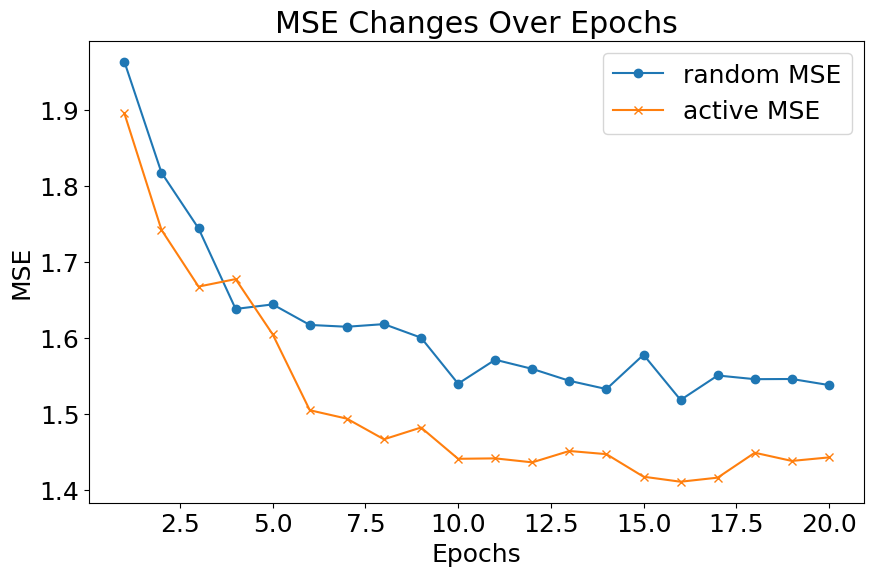

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(list(range(1, len(random_CDC_MSE)+1)), random_CDC_MSE, label='random MSE', marker='o')
plt.plot(list(range(1, len(active_CDC_MSE)+1)), active_CDC_MSE, label='active MSE', marker='x')

# for i in range(len(random_CDC_MSE)):
#     plt.text(i, random_CDC_MSE[i], f'{random_CDC_MSE[i]:.2f}', ha='center', va='bottom')
#     plt.text(i, active_CDC_MSE[i], f'{active_CDC_MSE[i]:.2f}', ha='center', va='top')

# 添加标题和标签
plt.title('MSE Changes Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
clear_output(wait=True)
plt.show()

## Comprehensive

In [9]:
# load embedding
emb_list = pd.concat([CDC_all_final['seq_id_a'], CDC_all_final['seq_id_b'], CDC_all_final['seq_id_c'], CDC_all_final['seq_id_d']], axis=0).unique().tolist()
emb_list = ['matrix_' + item +'.pt' for item in emb_list]
IDs, embeddings = load_embedding("/data/chenyihao/embedding", files=emb_list)
embeddings = [emb.to(device) for emb in embeddings]
emb_dict = dict(zip(IDs, embeddings))

Loading tensor: 100%|██████████| 1757/1757 [04:13<00:00,  6.93file/s]


In [ ]:
dropout_rate = 0.5
for module in model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.p = dropout_rate

CDC_sample_dataloader = DataLoader(LucaDataset(CDC_candidate), batch_size=80)
CDCS_preds, CDCS_labels = monte_carlo_preds(model, CDC_sample_dataloader, T=20)

In [ ]:
CDC_pred_df = list2df(CDCS_preds,len(CDC_sample_dataloader))
CDC_var = CDC_pred_df.var(axis=0)
print('The mean variance of test set is: ', CDC_var.mean())

The mean variance of test set is:  0.4657105126649325


In [125]:
test_df = CDC_candidate.copy()
test_df['uncertainty'] = CDC_var.tolist()

H1N1_uncertainty = test_df[test_df['serumType'] == 'H1N1']['uncertainty']
H3N2_uncertainty = test_df[test_df['serumType'] == 'H3N2']['uncertainty']
print(H1N1_uncertainty.mean())
print(H3N2_uncertainty.mean())

0.4111977291719905
0.4954049883863767


In [126]:
from scipy import stats

levene_stat, levene_p = stats.levene(H1N1_uncertainty, H3N2_uncertainty)
print("Levene p =", levene_p)
equal_var = levene_p > 0.05   # >0.05 认为方差齐

t_stat, p_val = stats.ttest_ind(H1N1_uncertainty, H3N2_uncertainty, equal_var=equal_var)
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")

Levene p = 0.10768673370105787
t = -15.064, p = 0.0000


In [127]:
serumNames = test_df['serumName'].unique().tolist()

serum_Uncertainty = []
for serum in serumNames:
    serum_Uncertainty.append(test_df[test_df['serumName'] == serum]['uncertainty'].mean())

Uncertainty_dict = {key: value for key, value in zip(serumNames, serum_Uncertainty)}

In [107]:
top10 = dict(sorted(Uncertainty_dict.items(), key=lambda x: x[1], reverse=True)[:10])

In [137]:
import importlib
import model_001
importlib.reload(model_001)
from model_001 import *

In [164]:
del model

In [143]:
model = torch.load('/data/chenyihao/fluProfiler_source/model/model_001.pth', weights_only=False, map_location=device)

In [132]:
filted_sample = CDC_candidate[CDC_candidate['serumName'].isin(top10.keys())].copy()
print(len(filted_sample))
Dataset_4_concat_vector = LucaDataset(filted_sample)
Dataloader_4_concat_vector = DataLoader(Dataset_4_concat_vector, batch_size=100, shuffle=False)

2331


In [145]:
from utilities import print_exams

test_prediction_ls = []
test_reference_ls = []
test_logits_ls = []
model.eval()
for batch in Dataloader_4_concat_vector:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])
    
    # matrixs_a = matrixs_a.to(device)
    # matrixs_b = matrixs_b.to(device)
    # matrixs_c = matrixs_c.to(device)
    # matrixs_d = matrixs_d.to(device)

    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)
    
    strainPassCats = strainPassCats.to(device)
    
    labels = labels.to(device)
    
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                    matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                    matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, labels=labels,
                                    save_concat_vector='/data/chenyihao/fluProfiler_source/data/processed/3.1')
    
    test_prediction_ls = test_prediction_ls + output.view(-1).tolist()
    test_reference_ls = test_reference_ls + labels.tolist()
    test_logits_ls.append(logits.tolist())

print_exams(test_prediction_ls, test_reference_ls)

MAE:  1.2479186165919636
MSE:  2.519025994714801
pearson correlation:  PearsonRResult(statistic=0.5781270822759106, pvalue=5.203192254088627e-208)
spearman correlation:  SignificanceResult(statistic=0.5473255580398375, pvalue=2.5720816766868268e-182)
R2_score:  0.276612947557176


In [149]:
dict_path = '/data/chenyihao/fluProfiler_source/data/processed/3.1'
files = os.listdir(dict_path)
files = sorted(files, key=lambda x: int(x.replace('.pth', '')))
my_tensors = []
for file in files:
    my_tensors.append(torch.load(os.path.join(dict_path, file), weights_only=False))
CDC_candidate_tensor = torch.cat(my_tensors, dim=0).cpu().numpy()
print(CDC_candidate_tensor.shape)

(2331, 1024)


In [150]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

kmeans = KMeans(n_clusters=500, random_state=42, n_init=10)
kmeans.fit(CDC_candidate_tensor)
centers = kmeans.cluster_centers_
distances = cdist(centers, CDC_candidate_tensor)
representative = distances.argmin(axis=1)

CDC_active_selected = CDC_candidate.iloc[representative]
CDC_random_selected = CDC_candidate.sample(500, random_state=42)

In [159]:
CDC_active_dataloader = DataLoader(LucaDataset(CDC_active_selected), batch_size=8, shuffle=True)

In [171]:
import numpy as np
del model

In [172]:
import pickle

model = torch.load('/data/chenyihao/fluProfiler_source/model/model_001.pth', weights_only=False, map_location=device)
with open("../Section1_BestPractice/1.6_Pretrained_model_compare/args.pkl", "rb") as file:
    fluProfiler_args = pickle.load(file)

no_decay = ["bias", "layernorm.weight", "layer_norm.weight", "layer.norm.weight"]
optimizer_grouped_parameters = [{
            "params": [p for n, p in model.named_parameters() if not any(nd in n.lower() for nd in no_decay)],
            "weight_decay": fluProfiler_args.weight_decay
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n.lower() for nd in no_decay)],
            "weight_decay": 0.0
        }
    ]
optimizer = AdamW(optimizer_grouped_parameters,
                    lr=0.00008,
                    betas=[fluProfiler_args.beta1 if fluProfiler_args.beta1 > 0 else 0.9, fluProfiler_args.beta2 if fluProfiler_args.beta2 > 0 else 0.98],
                    eps=fluProfiler_args.adam_epsilon)

epochs = 20

num_training_steps = len(CDC_active_dataloader) * epochs
progress_bar = tqdm(range(num_training_steps)) 

for epoch in range(epochs):
    model.train()
    loss_ls = []
    for batch in CDC_active_dataloader:
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch

        matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])
        
        # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
        masks_a = masks_a.to(device)
        masks_b = masks_b.to(device)
        masks_c = masks_c.to(device)
        masks_d = masks_d.to(device)

        strainPassCats = strainPassCats.to(device)

        labels = labels.to(device)
        
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, matrices_d=matrixs_d, 
                                     matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                     matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, 
                                     strainPassCats=strainPassCats, labels=labels)
    
        loss.backward()
        loss_ls.append(loss.item())
        optimizer.step()
        optimizer.zero_grad()
        progress_bar.update(1)
    train_loss = np.mean(loss_ls)
    print('train loss :', train_loss)

    prediction_ls = []
    reference_ls = []
    logits_ls = []
    loss_ls_valid = []
    model.eval()
    for batch in CDC_test_dataloader:
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
        
        matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

        # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
        masks_a = masks_a.to(device)
        masks_b = masks_b.to(device)
        masks_c = masks_c.to(device)
        masks_d = masks_d.to(device)

        strainPassCats = strainPassCats.to(device)

        labels = labels.to(device)
        with torch.no_grad():
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                         matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                         matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                         labels=labels)
    
        loss_ls_valid.append(loss.item())
        logits_ls.append(logits.tolist())
        prediction_ls = prediction_ls + output.view(-1).tolist()
        reference_ls = reference_ls + labels.tolist()

    print_exams(reference_ls, prediction_ls)

  5%|▍         | 62/1260 [00:05<01:45, 11.32it/s]

train loss : 1.901497194218257


  5%|▌         | 64/1260 [00:21<50:04,  2.51s/it]

MAE:  1.0399863313689066
MSE:  1.8542947360441067
pearson correlation:  PearsonRResult(statistic=0.7613846506858506, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.7638977423790425, pvalue=0.0)
R2_score:  0.39453270560635123


 10%|█         | 126/1260 [00:27<01:34, 12.03it/s]

...

train loss : 0.47613974944466636


 95%|█████████▌| 1198/1260 [06:55<03:03,  2.96s/it]

MAE:  0.9123940636709265
MSE:  1.4468753770166172
pearson correlation:  PearsonRResult(statistic=0.8232726572741003, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.8157358088594718, pvalue=0.0)
R2_score:  0.5782149766209432


100%|██████████| 1260/1260 [07:01<00:00, 11.68it/s]

train loss : 0.4571834540674611
MAE:  0.9003139719842838
MSE:  1.4251057602843133
pearson correlation:  PearsonRResult(statistic=0.822997169320426, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.8154689392545875, pvalue=0.0)
R2_score:  0.5860906995559002
